# Install Dependencies

In [1]:
import numpy as np
import gym
import pickle
import matplotlib.pyplot as plt

import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque

from gym import logger as gymlogger
from gym.wrappers import RecordVideo
gymlogger.set_level(40) #error only
import glob
import io
import base64
from IPython.display import HTML
from IPython import display as ipythondisplay

def show_video():
  mp4list = glob.glob('video/*.mp4')
  if len(mp4list) > 0:
    mp4 = mp4list[0]
    video = io.open(mp4, 'r+b').read()
    encoded = base64.b64encode(video)
    ipythondisplay.display(HTML(data=''''''.format(encoded.decode('ascii'))))
  else:
    print("Could not find video")

# Initialize CartPole Environment

In [2]:
# observation space

env = gym.make('CartPole-v1')
print("Shape of action space: ", env.action_space)
print("Shape of observation space: ", env.observation_space.shape[0])

Shape of action space:  Discrete(2)
Shape of observation space:  4


# Task 1: Development of an RL Agent

Demonstrate the correctness of the implementation by sampling a random state from the cart pole environment, inputting to the agent, and outputting a chosen action. Print the values of the state and chosen action in Jupyter notebook.



## 1.1 DEEP Q-Learning (DQL) Agent for CartPole

- Uses a neural network instead of a Q-table.
- Implements experience replay to improve stability.
- Uses a target network to stabilize learning.
- Uses epsilon-greedy policy for exploration.

### DQL Implementation

In [3]:
# Neural Network for Q-value approximation
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_size, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_size)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

class DQLAgent:
    def __init__(self, env, gamma=0.99, lr=0.001, batch_size=64, memory_size=10000,
                 epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01, target_update_freq=10):
        self.env = env
        self.state_size = env.observation_space.shape[0]
        self.action_size = env.action_space.n
        self.gamma = gamma  # Discount factor
        self.epsilon = epsilon  # Exploration rate
        self.epsilon_decay = epsilon_decay  # Decay rate for epsilon
        self.epsilon_min = epsilon_min  # Minimum exploration rate
        self.batch_size = batch_size  # Batch size for training
        self.target_update_freq = target_update_freq  # Target network update frequency
        self.lr = lr  # Store learning rate

        # Memory for experience replay
        self.memory = deque(maxlen=memory_size)

        # Q-network (main network)
        self.q_network = DQN(self.state_size, self.action_size)
        self.target_network = DQN(self.state_size, self.action_size)
        self.target_network.load_state_dict(self.q_network.state_dict())  # Copy weights
        self.target_network.eval()  # Target network does not update with gradients

        # Optimizer with custom learning rate
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)

    def set_learning_rate(self, new_lr):
        """ Update the learning rate of the optimizer dynamically. """
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = new_lr


    def select_action(self, state, training=True):
        """ Select action using epsilon-greedy policy """
        if training and np.random.rand() < self.epsilon:
            return self.env.action_space.sample()  # Random action
        else:
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            with torch.no_grad():
                q_values = self.q_network(state_tensor)
            return torch.argmax(q_values).item()

    def store_experience(self, state, action, reward, next_state, done):
        """ Store experience in replay memory with uniform shapes """
        self.memory.append((
            np.array(state, dtype=np.float32).reshape(self.state_size),  # Ensure shape (4,)
            action,
            reward,
            np.array(next_state, dtype=np.float32).reshape(self.state_size),  # Ensure shape (4,)
            done
        ))

    def train_step(self):
        """ Train the agent using a batch of experiences """
        if len(self.memory) < self.batch_size:
            return

        # Sample mini-batch from memory
        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        # Convert states and next_states to uniform NumPy arrays before stacking
        states = torch.FloatTensor(np.array(states, dtype=np.float32).reshape(self.batch_size, -1))
        actions = torch.LongTensor(np.array(actions)).unsqueeze(1)
        rewards = torch.FloatTensor(np.array(rewards)).unsqueeze(1)
        next_states = torch.FloatTensor(np.array(next_states, dtype=np.float32).reshape(self.batch_size, -1))
        dones = torch.FloatTensor(np.array(dones)).unsqueeze(1)

        # Compute Q-values
        q_values = self.q_network(states).gather(1, actions)

        # Compute target Q-values
        with torch.no_grad():
            next_q_values = self.target_network(next_states).max(1)[0].unsqueeze(1)
            target_q_values = rewards + (self.gamma * next_q_values * (1 - dones))

        # Compute loss
        loss = F.mse_loss(q_values, target_q_values)

        # Backpropagation
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def train(self, num_episodes=500):
        """ Train the agent using Deep Q-Learning """
        rewards_per_episode = []
        for episode in range(num_episodes):
            reset_output = self.env.reset()

            # Check if Gym returns (state, info) or just state
            if isinstance(reset_output, tuple):
                state = reset_output[0]  # Gymnasium (state, info)
            else:
                state = reset_output  # Older Gym versions

            state = np.array(state, dtype=np.float32).reshape(-1)  # Flatten state
            total_reward = 0
            done = False

            while not done:
                action = self.select_action(state)

                # Handle both Gym and Gymnasium versions
                step_result = self.env.step(action)
                if len(step_result) == 4:
                    next_state, reward, done, info = step_result
                else:
                    next_state, reward, done, truncated, info = step_result
                    done = done or truncated  # Merge `done` and `truncated` flags

                next_state = np.array(next_state, dtype=np.float32).reshape(-1)  # Ensure consistent shape
                self.store_experience(state, action, reward, next_state, done)
                state = next_state
                total_reward += reward

                self.train_step()

            rewards_per_episode.append(total_reward)

            # Update target network
            if episode % self.target_update_freq == 0:
                self.target_network.load_state_dict(self.q_network.state_dict())

            # Decay epsilon
            self.epsilon = max(self.epsilon * self.epsilon_decay, self.epsilon_min)

            # Print progress every 10 episodes
            if episode % 10 == 0:
                print(f"Episode {episode}/{num_episodes}, Total Reward: {total_reward}, Epsilon: {self.epsilon:.2f}")

        self.plot_rewards(rewards_per_episode)



    def test(self, num_episodes=10):
        """ Test the agent without training """
        for episode in range(num_episodes):
            reset_output = self.env.reset()

            # Check if Gym returns (state, info) or just state
            if isinstance(reset_output, tuple):
                state = reset_output[0]  # Gymnasium (state, info)
            else:
                state = reset_output  # Older Gym versions

            state = np.array(state, dtype=np.float32).reshape(-1)  # Ensure state is (4,)
            total_reward = 0
            done = False

            while not done:
                action = self.select_action(state, training=False)

                step_result = self.env.step(action)
                if len(step_result) == 4:
                    next_state, reward, done, info = step_result
                else:
                    next_state, reward, done, truncated, info = step_result
                    done = done or truncated  # Merge `done` and `truncated` flags

                state = np.array(next_state, dtype=np.float32).reshape(-1)  # Ensure next state is (4,)
                total_reward += reward

            print(f"Episode {episode+1}, Total Reward: {total_reward}")


    def plot_rewards(self, rewards):
        """ Plot the rewards over episodes """
        plt.plot(rewards)
        plt.xlabel('Episodes')
        plt.ylabel('Rewards')
        plt.title('Training Rewards over Episodes')
        plt.show()

    def save_model(self, filename='dql_cartpole.pth'):
        """ Save trained model """
        torch.save(self.q_network.state_dict(), filename)

    def load_model(self, filename='dql_cartpole.pth'):
        """ Load trained model """
        self.q_network.load_state_dict(torch.load(filename))
        self.q_network.eval()

### Create & Train Agent

/usr/local/lib/python3.11/dist-packages/gym/utils/passive_env_checker.py:241: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


Episode 0/500, Total Reward: 33.0, Epsilon: 0.99
Episode 10/500, Total Reward: 17.0, Epsilon: 0.95
Episode 20/500, Total Reward: 11.0, Epsilon: 0.90
Episode 30/500, Total Reward: 18.0, Epsilon: 0.86
Episode 40/500, Total Reward: 21.0, Epsilon: 0.81
Episode 50/500, Total Reward: 59.0, Epsilon: 0.77
Episode 60/500, Total Reward: 27.0, Epsilon: 0.74
Episode 70/500, Total Reward: 14.0, Epsilon: 0.70
Episode 80/500, Total Reward: 41.0, Epsilon: 0.67
Episode 90/500, Total Reward: 58.0, Epsilon: 0.63
Episode 100/500, Total Reward: 37.0, Epsilon: 0.60
Episode 110/500, Total Reward: 84.0, Epsilon: 0.57
Episode 120/500, Total Reward: 95.0, Epsilon: 0.55
Episode 130/500, Total Reward: 23.0, Epsilon: 0.52
Episode 140/500, Total Reward: 125.0, Epsilon: 0.49
Episode 150/500, Total Reward: 105.0, Epsilon: 0.47
Episode 160/500, Total Reward: 65.0, Epsilon: 0.45
Episode 170/500, Total Reward: 237.0, Epsilon: 0.42
Episode 180/500, Total Reward: 170.0, Epsilon: 0.40
Episode 190/500, Total Reward: 148.0, 

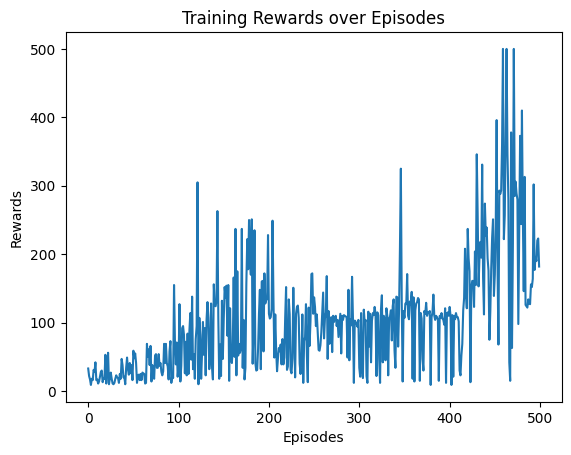

In [4]:
env = gym.make('CartPole-v1')
agent = DQLAgent(env)
agent.train(num_episodes=500)  # Train the agent

### Test Trained Agent

In [ ]:
agent.test(num_episodes=10)

Episode 1, Total Reward: 142.0
Episode 2, Total Reward: 137.0
Episode 3, Total Reward: 131.0
Episode 4, Total Reward: 130.0
Episode 5, Total Reward: 136.0
Episode 6, Total Reward: 128.0
Episode 7, Total Reward: 150.0
Episode 8, Total Reward: 143.0
Episode 9, Total Reward: 134.0
Episode 10, Total Reward: 130.0


### Save & Load Trained Model

In [ ]:
agent.save_model('dql_cartpole.pth')
agent.load_model('dql_cartpole.pth')

### Corectness of Implementation

In [ ]:
state = env.reset()

# Check if Gym returns (state, info) or just state
if isinstance(state, tuple):
    state = state[0]  # Gymnasium (state, info)

state = np.array(state, dtype=np.float32).reshape(-1)  # Ensure state is (4,)
action = agent.select_action(state, training=False)
print("State:", state)
print("Action:", action)


State: [ 0.00717848 -0.00920251 -0.01350014 -0.02258828]
Action: 0


## 1.2 Hyperparameter Exploration and Tuning

### Vary Learning Rate


Training with Learning Rate = 0.05
Episode 0/10000, Total Reward: 11.0, Epsilon: 0.10
Episode 10/10000, Total Reward: 15.0, Epsilon: 0.09
Episode 20/10000, Total Reward: 19.0, Epsilon: 0.09
Episode 30/10000, Total Reward: 24.0, Epsilon: 0.09
Episode 40/10000, Total Reward: 14.0, Epsilon: 0.08
Episode 50/10000, Total Reward: 16.0, Epsilon: 0.08
Episode 60/10000, Total Reward: 69.0, Epsilon: 0.07
Episode 70/10000, Total Reward: 9.0, Epsilon: 0.07
Episode 80/10000, Total Reward: 13.0, Epsilon: 0.07
Episode 90/10000, Total Reward: 79.0, Epsilon: 0.06
Episode 100/10000, Total Reward: 39.0, Epsilon: 0.06
Episode 110/10000, Total Reward: 9.0, Epsilon: 0.06
Episode 120/10000, Total Reward: 12.0, Epsilon: 0.05
Episode 130/10000, Total Reward: 28.0, Epsilon: 0.05
Episode 140/10000, Total Reward: 61.0, Epsilon: 0.05
Episode 150/10000, Total Reward: 11.0, Epsilon: 0.05
Episode 160/10000, Total Reward: 76.0, Epsilon: 0.04
Episode 170/10000, Total Reward: 13.0, Epsilon: 0.04
Episode 180/10000, Tota

KeyboardInterrupt: 

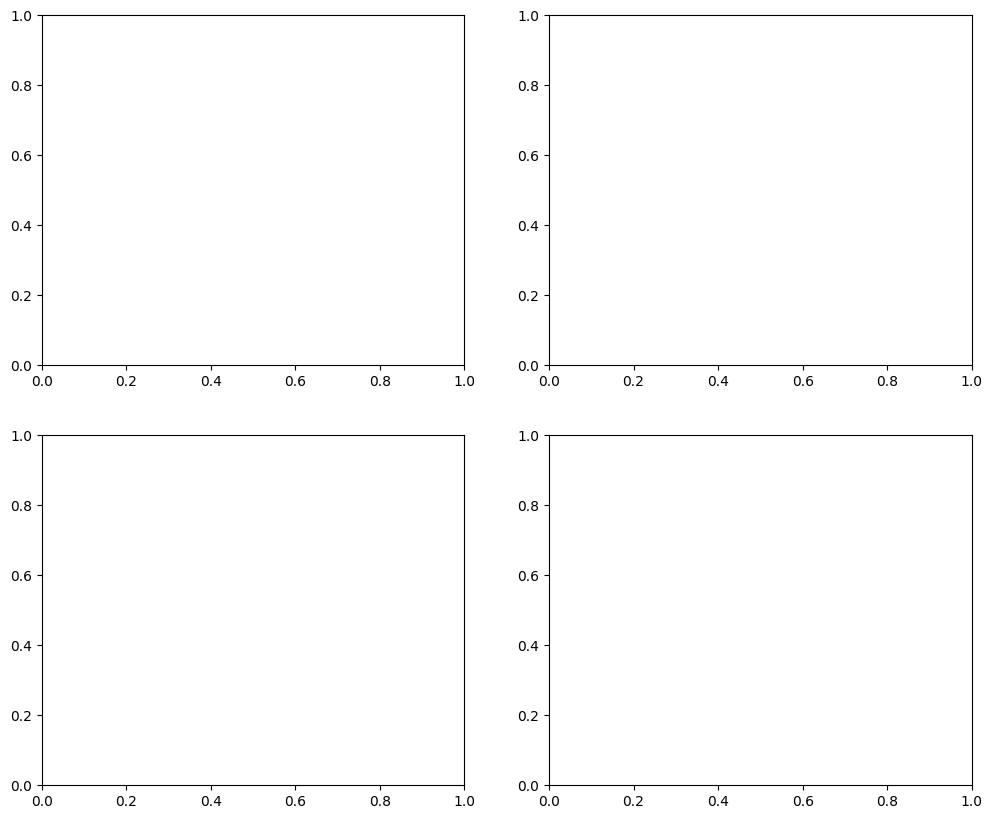

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define learning rates to test
learning_rates = [0.05, 0.1, 0.15, 0.2]

# Create subplots for plotting results
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Iterate over different learning rates
for i, lr in enumerate(learning_rates):
    print(f"\nTraining with Learning Rate = {lr}")

    # Initialize a new agent for each LR
    agent = DQLAgent(env, lr=lr, epsilon=0.1)  # Keep epsilon constant at 0.1

    # Train the agent and retrieve reward history
    rewards = agent.train(num_episodes=10000)  # Increase episodes to match reference

    # Compute the moving average for smooth plotting
    window_size = 100
    mean_rewards = np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')

    # Plot training rewards
    axes[i].plot(mean_rewards)
    axes[i].set_title(f"Mean Rewards vs Episodes (lr={lr}, er=0.10)")
    axes[i].set_xlabel("Episodes")
    axes[i].set_ylabel("Mean Rewards")

plt.tight_layout()
plt.show()


### Vary Initial Exploration Rate

### Choosing the best hyper parameters